In [18]:
import os
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [19]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# Для владельцев Mac
if torch.backends.mps.is_available():
    device = "mps"

print(f"System status: Ready. Device: {device}")

System status: Ready. Device: cuda


In [21]:
MODEL_NAME = "deepvk/RuModernBERT-base"

In [22]:
TRAIN_PATH = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_train.csv'
TEST_PATH = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_test.csv'

In [23]:
print(f"🔧 Проверка конфигурации путей...")
files_found = True

if os.path.exists(TRAIN_PATH):
    print(f"✅ TRAIN файл найден: {TRAIN_PATH}")
else:
    print(f"❌ ОШИБКА: TRAIN файл не найден по пути: {TRAIN_PATH}")
    print("   -> Проверьте каждую букву, особенно регистр (RuBert vs Rubert)!")
    files_found = False

if os.path.exists(TEST_PATH):
    print(f"✅ TEST файл найден: {TEST_PATH}")
else:
    print(f"❌ ОШИБКА: TEST файл не найден по пути: {TEST_PATH}")
    files_found = False

if files_found:
    print("\n🎉 Конфигурация успешна!")
else:
    print("\n⛔️ ОСТАНОВКА. Исправьте пути в этом блоке и запустите его снова!")

🔧 Проверка конфигурации путей...
✅ TRAIN файл найден: /content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_train.csv
✅ TEST файл найден: /content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_test.csv

🎉 Конфигурация успешна!


In [24]:
print(f"Loading from: {TRAIN_PATH}")

try:
    # 1. Загрузка данных
    dataset = load_dataset('csv', data_files={'train': TRAIN_PATH, 'test': TEST_PATH})

    # 2. Определяем словарь для перевода слов в цифры
    # ВАЖНО: Ключи должны быть в нижнем регистре, как в датасете
    label2id = {
        "neutral": 0,
        "positive": 1,
        "negative": 2,
        "speech": 3,
        "skip": 4
    }
    id2label = {v: k for k, v in label2id.items()}

    # 3. Функция "переводчик"
    def encode_labels(batch):
        new_labels = []
        for item in batch['label']:
            # Если метка — это строка (например, 'positive')
            if isinstance(item, str):
                clean_item = item.lower().strip() # Убираем пробелы и капс
                if clean_item in label2id:
                    new_labels.append(label2id[clean_item])
                else:
                    # Если встретилось что-то неизвестное, помечаем как 'skip' (4)
                    new_labels.append(4)

            # Если метка — уже число (int), оставляем как есть
            elif isinstance(item, (int, float)):
                new_labels.append(int(item))

            # Если метка — список (бывает при странном форматировании CSV), берем первый элемент
            elif isinstance(item, list):
                val = item[0]
                if isinstance(val, str) and val.lower().strip() in label2id:
                     new_labels.append(label2id[val.lower().strip()])
                else:
                     new_labels.append(int(val)) # Пытаемся как число
            else:
                new_labels.append(4) # Fallback

        batch['label'] = new_labels
        return batch

    print("🛠 Конвертация текстовых меток в числовые (Encoding)...")
    dataset = dataset.map(encode_labels, batched=True)

    # 4. Создаем валидационную выборку (10% от train)
    print("✂️ Разделение на train/validation...")
    split = dataset['train'].train_test_split(test_size=0.1, seed=RANDOM_SEED)
    dataset['train'] = split['train']
    dataset['validation'] = split['test']

    print("✅ Dataset loaded and processed successfully.")
    print("Example label (processed):", dataset['train'][0]['label']) # Должно быть число (например, 1 или 2)
    print("Structure:", dataset)

except Exception as e:
    print(f"❌ Критическая ошибка при обработке данных: {e}")

Loading from: /content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_train.csv
🛠 Конвертация текстовых меток в числовые (Encoding)...
✂️ Разделение на train/validation...
✅ Dataset loaded and processed successfully.
Example label (processed): 2
Structure: DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'id'],
        num_rows: 9641
    })
    test: Dataset({
        features: ['text', 'label', 'id'],
        num_rows: 2679
    })
    validation: Dataset({
        features: ['text', 'label', 'id'],
        num_rows: 1072
    })
})


In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding=False,
        truncation=True,
        max_length=128
    )

# remove_columns=['text'] удаляет сырой текст, оставляя только input_ids и labels
# Это предотвращает ошибки типов данных в Trainer
tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization complete.")
print("Feature keys:", tokenized_datasets['train'].features.keys())

Map:   0%|          | 0/2679 [00:00<?, ? examples/s]

Tokenization complete.
Feature keys: dict_keys(['label', 'id', 'input_ids', 'attention_mask'])


In [26]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": accuracy_score(labels, predictions), "f1": f1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id
).to(device)

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at deepvk/RuModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
# training_args = TrainingArguments(
#     output_dir="./rumodernbert_final",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5,
#     per_device_train_batch_size=32,
#     per_device_eval_batch_size=32,
#     num_train_epochs=4,
#     weight_decay=0.01,
#     load_best_model_at_end=True,
#     metric_for_best_model="f1",
#     save_total_limit=2,
#     seed=RANDOM_SEED,
#     report_to="none"
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_datasets["train"],
#     eval_dataset=tokenized_datasets["validation"],
#     tokenizer=tokenizer,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics,
# )

# trainer.train()

In [28]:
training_args = TrainingArguments(
    output_dir="./rumodernbert_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    seed=RANDOM_SEED,
    # === ВАЖНОЕ ОБНОВЛЕНИЕ ДЛЯ ГРАФИКОВ ===
    logging_strategy="steps",
    logging_steps=20,  # Пишем лог каждые 20 шагов (вместо 500 по умолчанию)
    # Это даст нам много точек для построения плавной кривой
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("🚀 Запуск обучения с детализированным логированием...")
trainer.train()

/tmp/ipython-input-1898404073.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


🚀 Запуск обучения с детализированным логированием...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.705800,0.750425,0.711754,0.701306
2,0.524800,0.725883,0.729478,0.724910
3,0.199700,0.976700,0.698694,0.702386
4,0.031100,1.608147,0.721082,0.721008


TrainOutput(global_step=1208, training_loss=0.4509569477067878, metrics={'train_runtime': 674.7457, 'train_samples_per_second': 57.153, 'train_steps_per_second': 1.79, 'total_flos': 1582950285592860.0, 'train_loss': 0.4509569477067878, 'epoch': 4.0})

In [29]:
model.save_pretrained("./rumodernbert_final")
tokenizer.save_pretrained("./rumodernbert_final")
print("Saved successfully.")

Saved successfully.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [31]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif' # Засечки для серьезности (как в LaTeX)

In [32]:
history = trainer.state.log_history
df = pd.DataFrame(history)

In [33]:
train_loss_data = df[df['loss'].notnull()][['epoch', 'loss']].copy()
eval_data = df[df['eval_loss'].notnull()][['epoch', 'eval_loss', 'eval_f1', 'eval_accuracy']]

In [34]:
# === СГЛАЖИВАНИЕ (Smoothing) ===
# Добавляем скользящее среднее, чтобы убрать шум SGD и сделать линию красивой
# span=10 означает сглаживание по окну в ~10 точек лога
train_loss_data['loss_smooth'] = train_loss_data['loss'].ewm(span=10).mean()

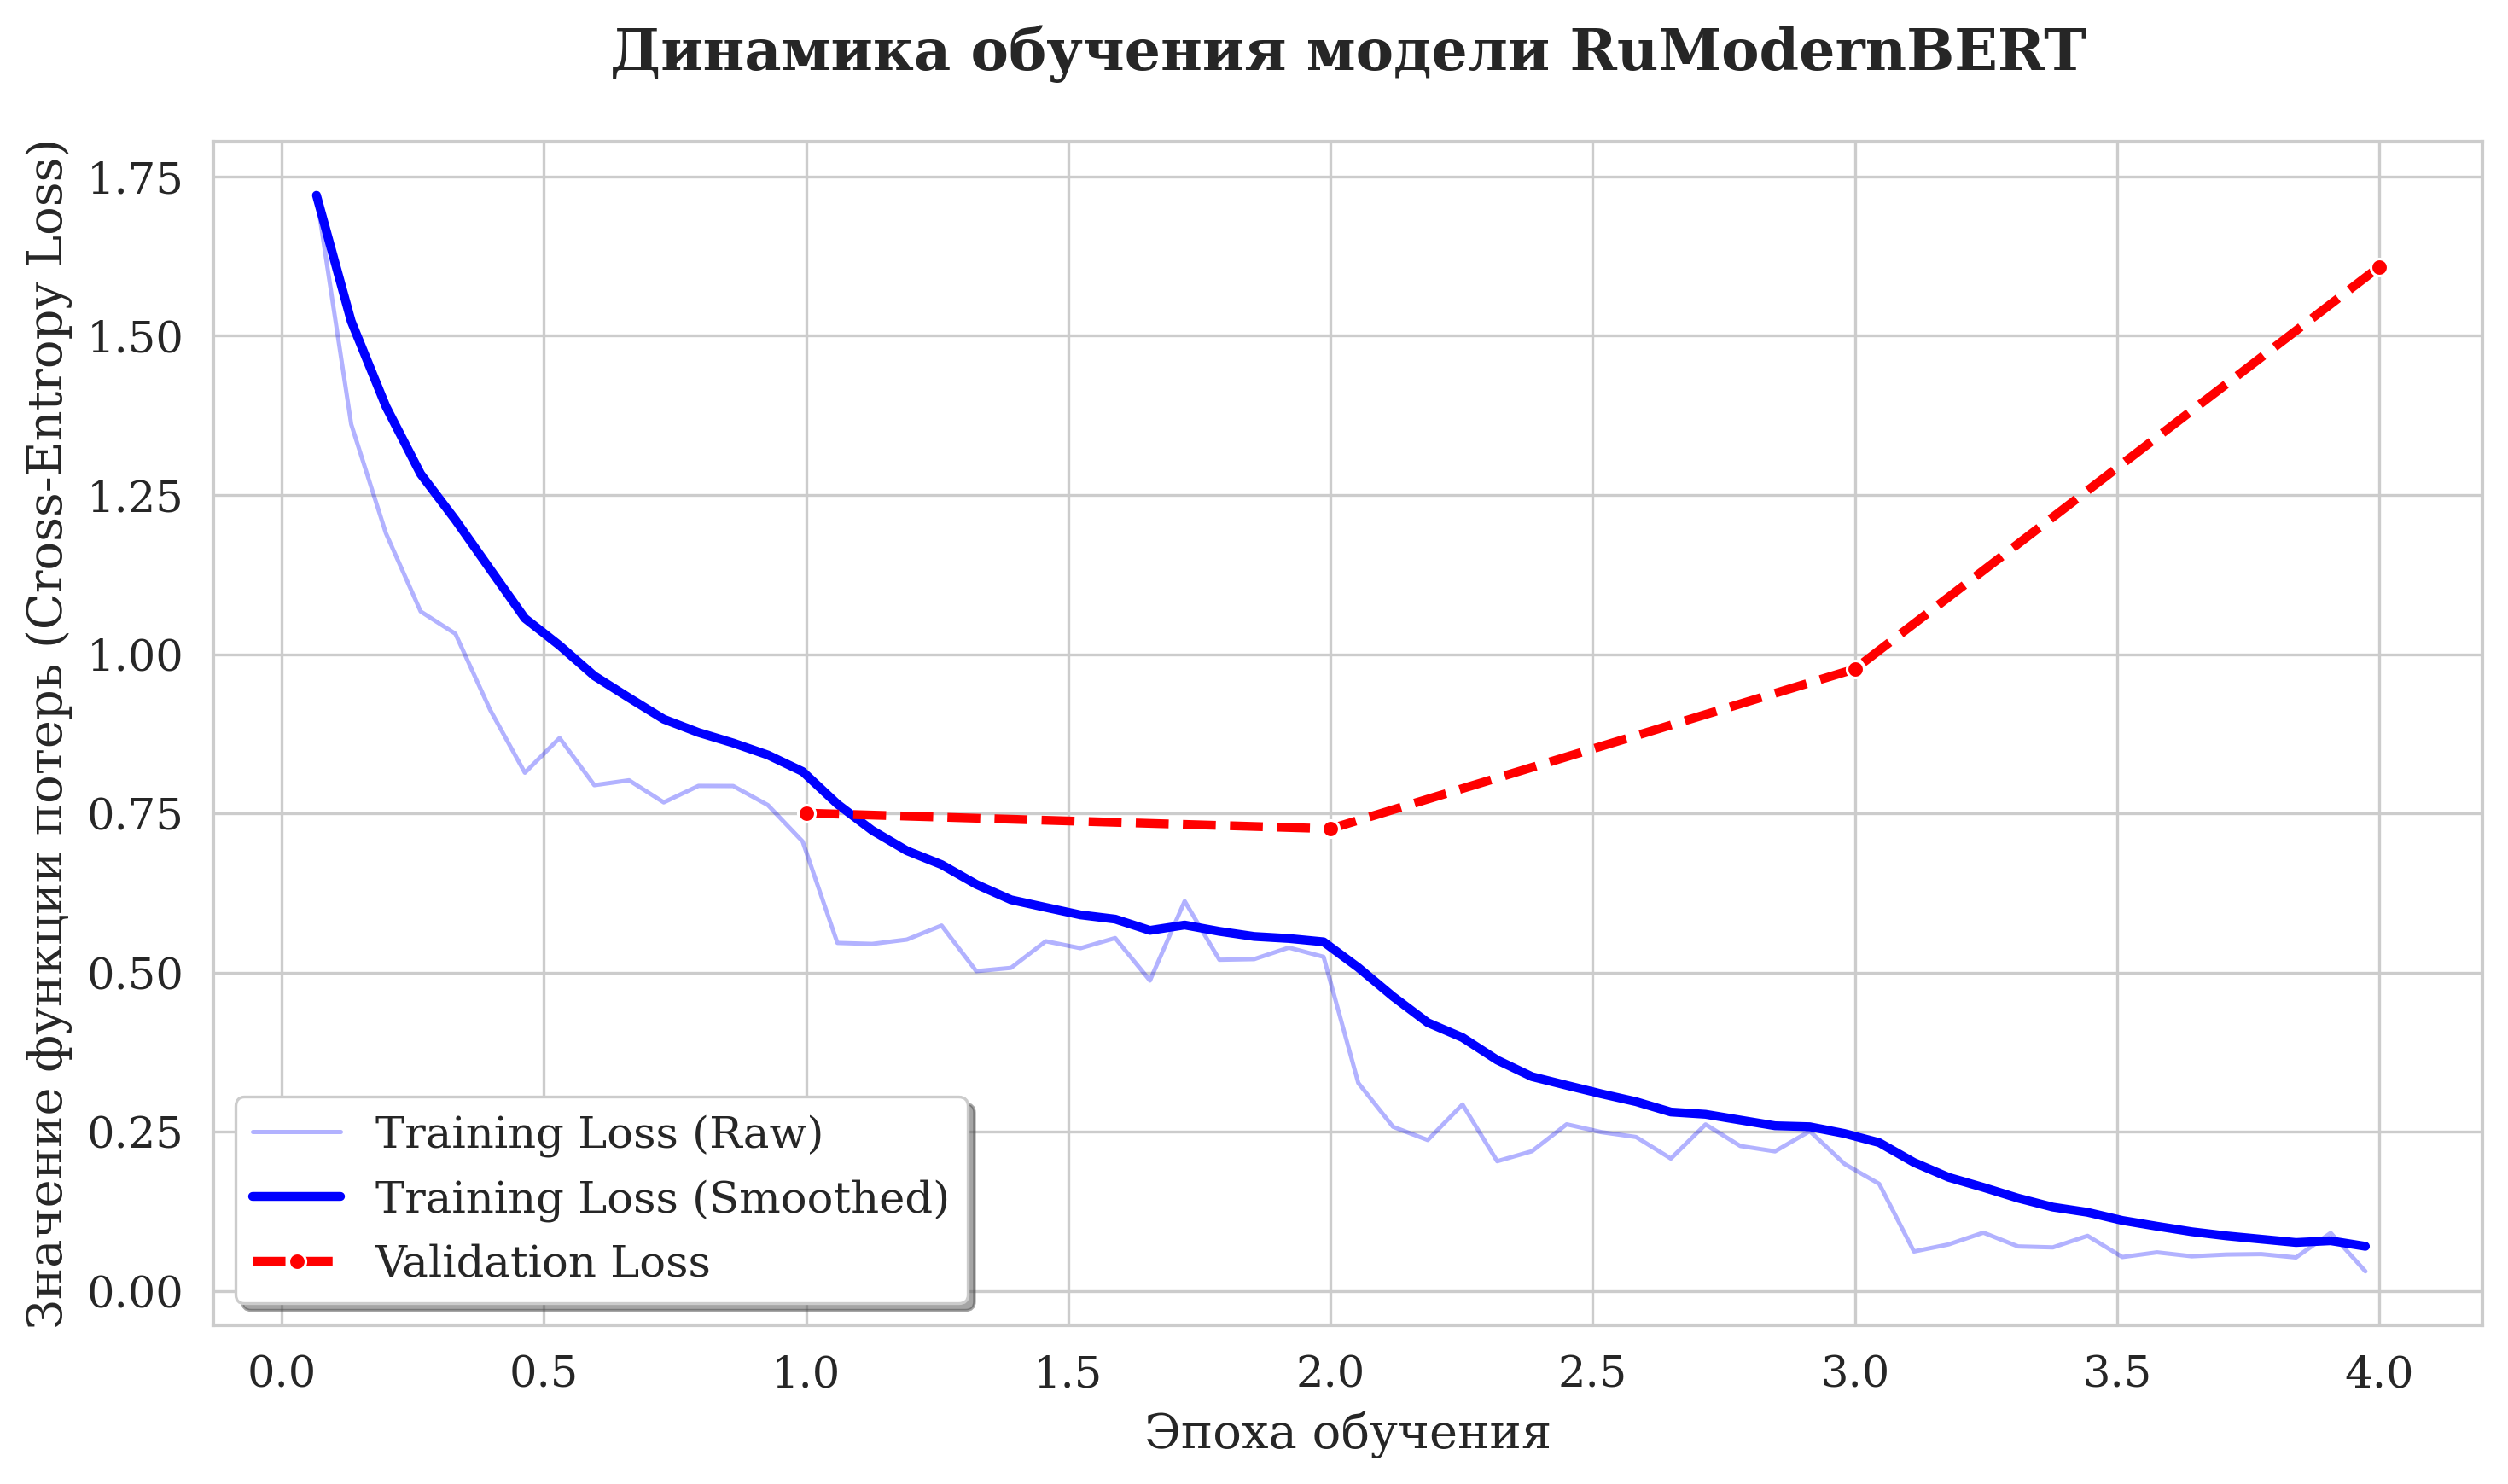

In [35]:
# --- График 1: Функция потерь (Loss) ---
plt.figure(figsize=(10, 6))

# Рисуем полупрозрачную реальную линию (шум)
sns.lineplot(data=train_loss_data, x='epoch', y='loss', alpha=0.3, color='blue', label='Training Loss (Raw)')
# Рисуем жирную сглаженную линию (Тренд)
sns.lineplot(data=train_loss_data, x='epoch', y='loss_smooth', color='blue', linewidth=2.5, label='Training Loss (Smoothed)')

# Валидация (она всегда более гладкая, так как считается раз в эпоху)
sns.lineplot(data=eval_data, x='epoch', y='eval_loss', color='red', linestyle='--', linewidth=2.5, marker='o', label='Validation Loss')

plt.title('Динамика обучения модели RuModernBERT', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение функции потерь (Cross-Entropy Loss)')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('thesis_loss_dynamics.png')
plt.show()

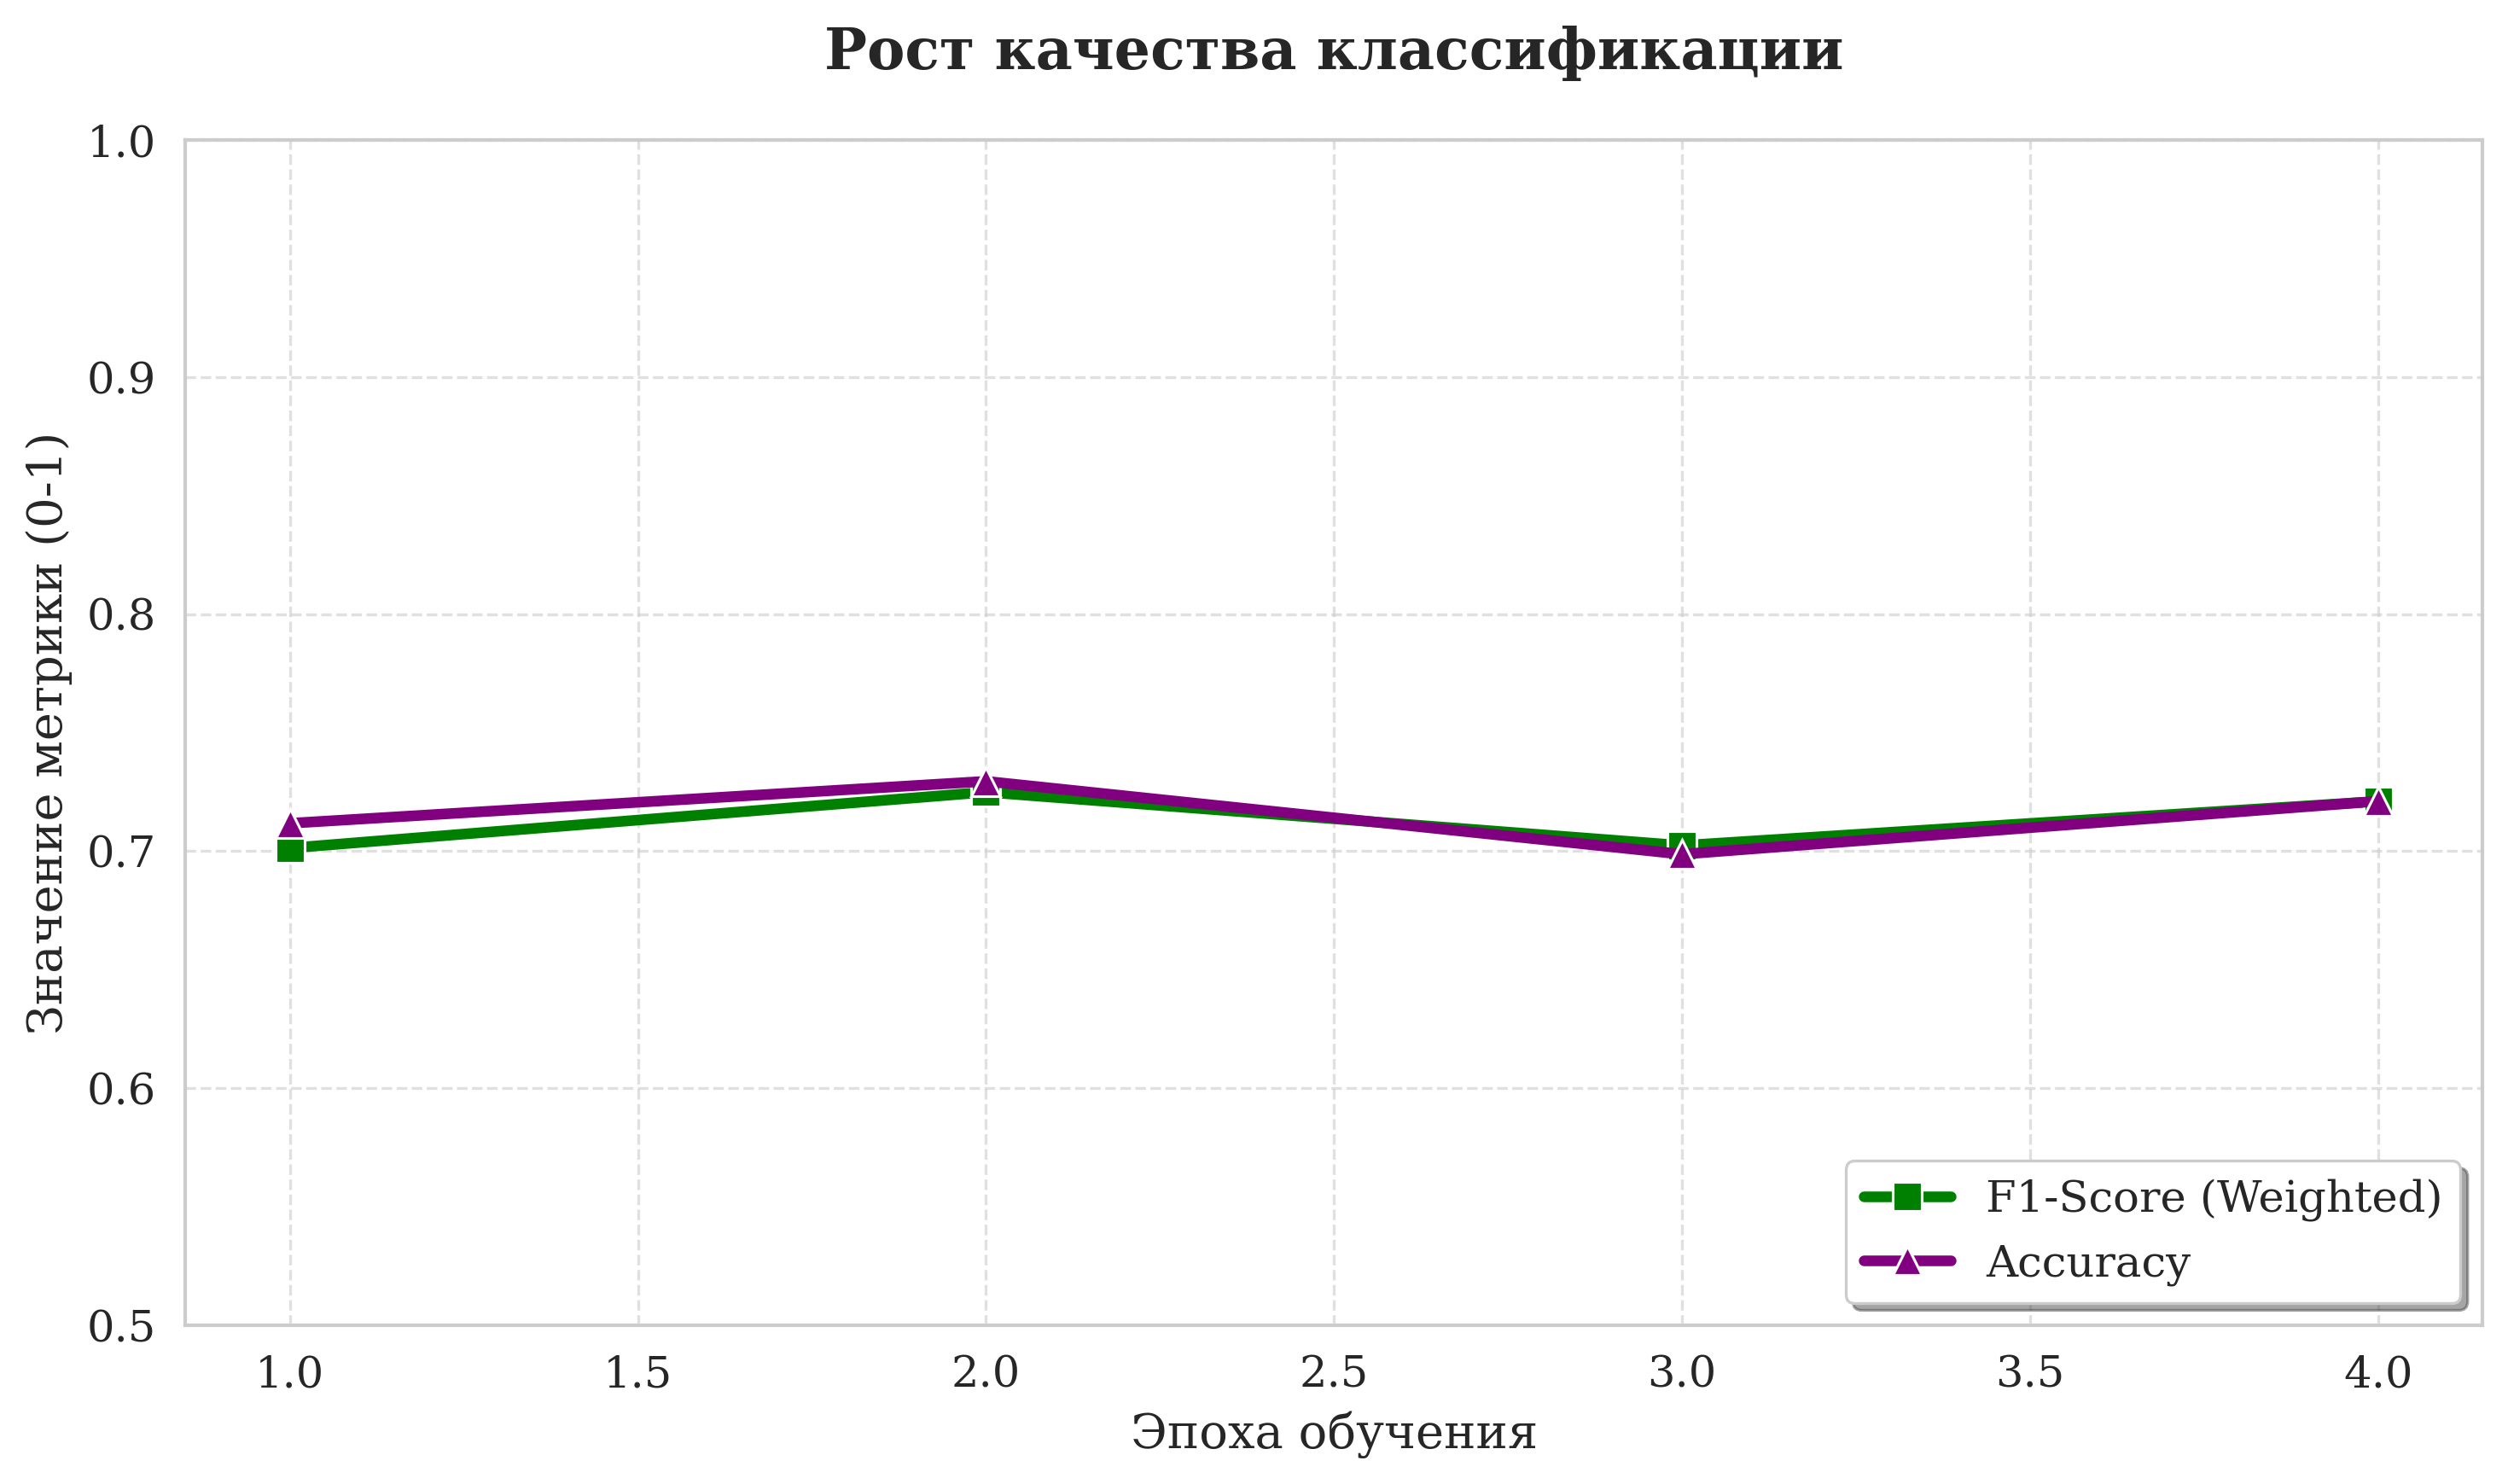

✅ Профессиональные графики сохранены: thesis_loss_dynamics.png, thesis_metrics_dynamics.png


In [36]:
# --- График 2: Метрики качества ---
plt.figure(figsize=(10, 6))

sns.lineplot(data=eval_data, x='epoch', y='eval_f1', label='F1-Score (Weighted)', color='green', linewidth=3, marker='s', markersize=8)
sns.lineplot(data=eval_data, x='epoch', y='eval_accuracy', label='Accuracy', color='purple', linewidth=3, marker='^', markersize=8)

plt.title('Рост качества классификации', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение метрики (0-1)')
plt.ylim(0.5, 1.0) # Масштабируем ось Y, чтобы было видно детали
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(frameon=True, shadow=True, loc='lower right')
plt.tight_layout()
plt.savefig('thesis_metrics_dynamics.png')
plt.show()

print("✅ Профессиональные графики сохранены: thesis_loss_dynamics.png, thesis_metrics_dynamics.png")

In [37]:
from sklearn.metrics import confusion_matrix

🔍 Выполняем предсказание на тестовом наборе...


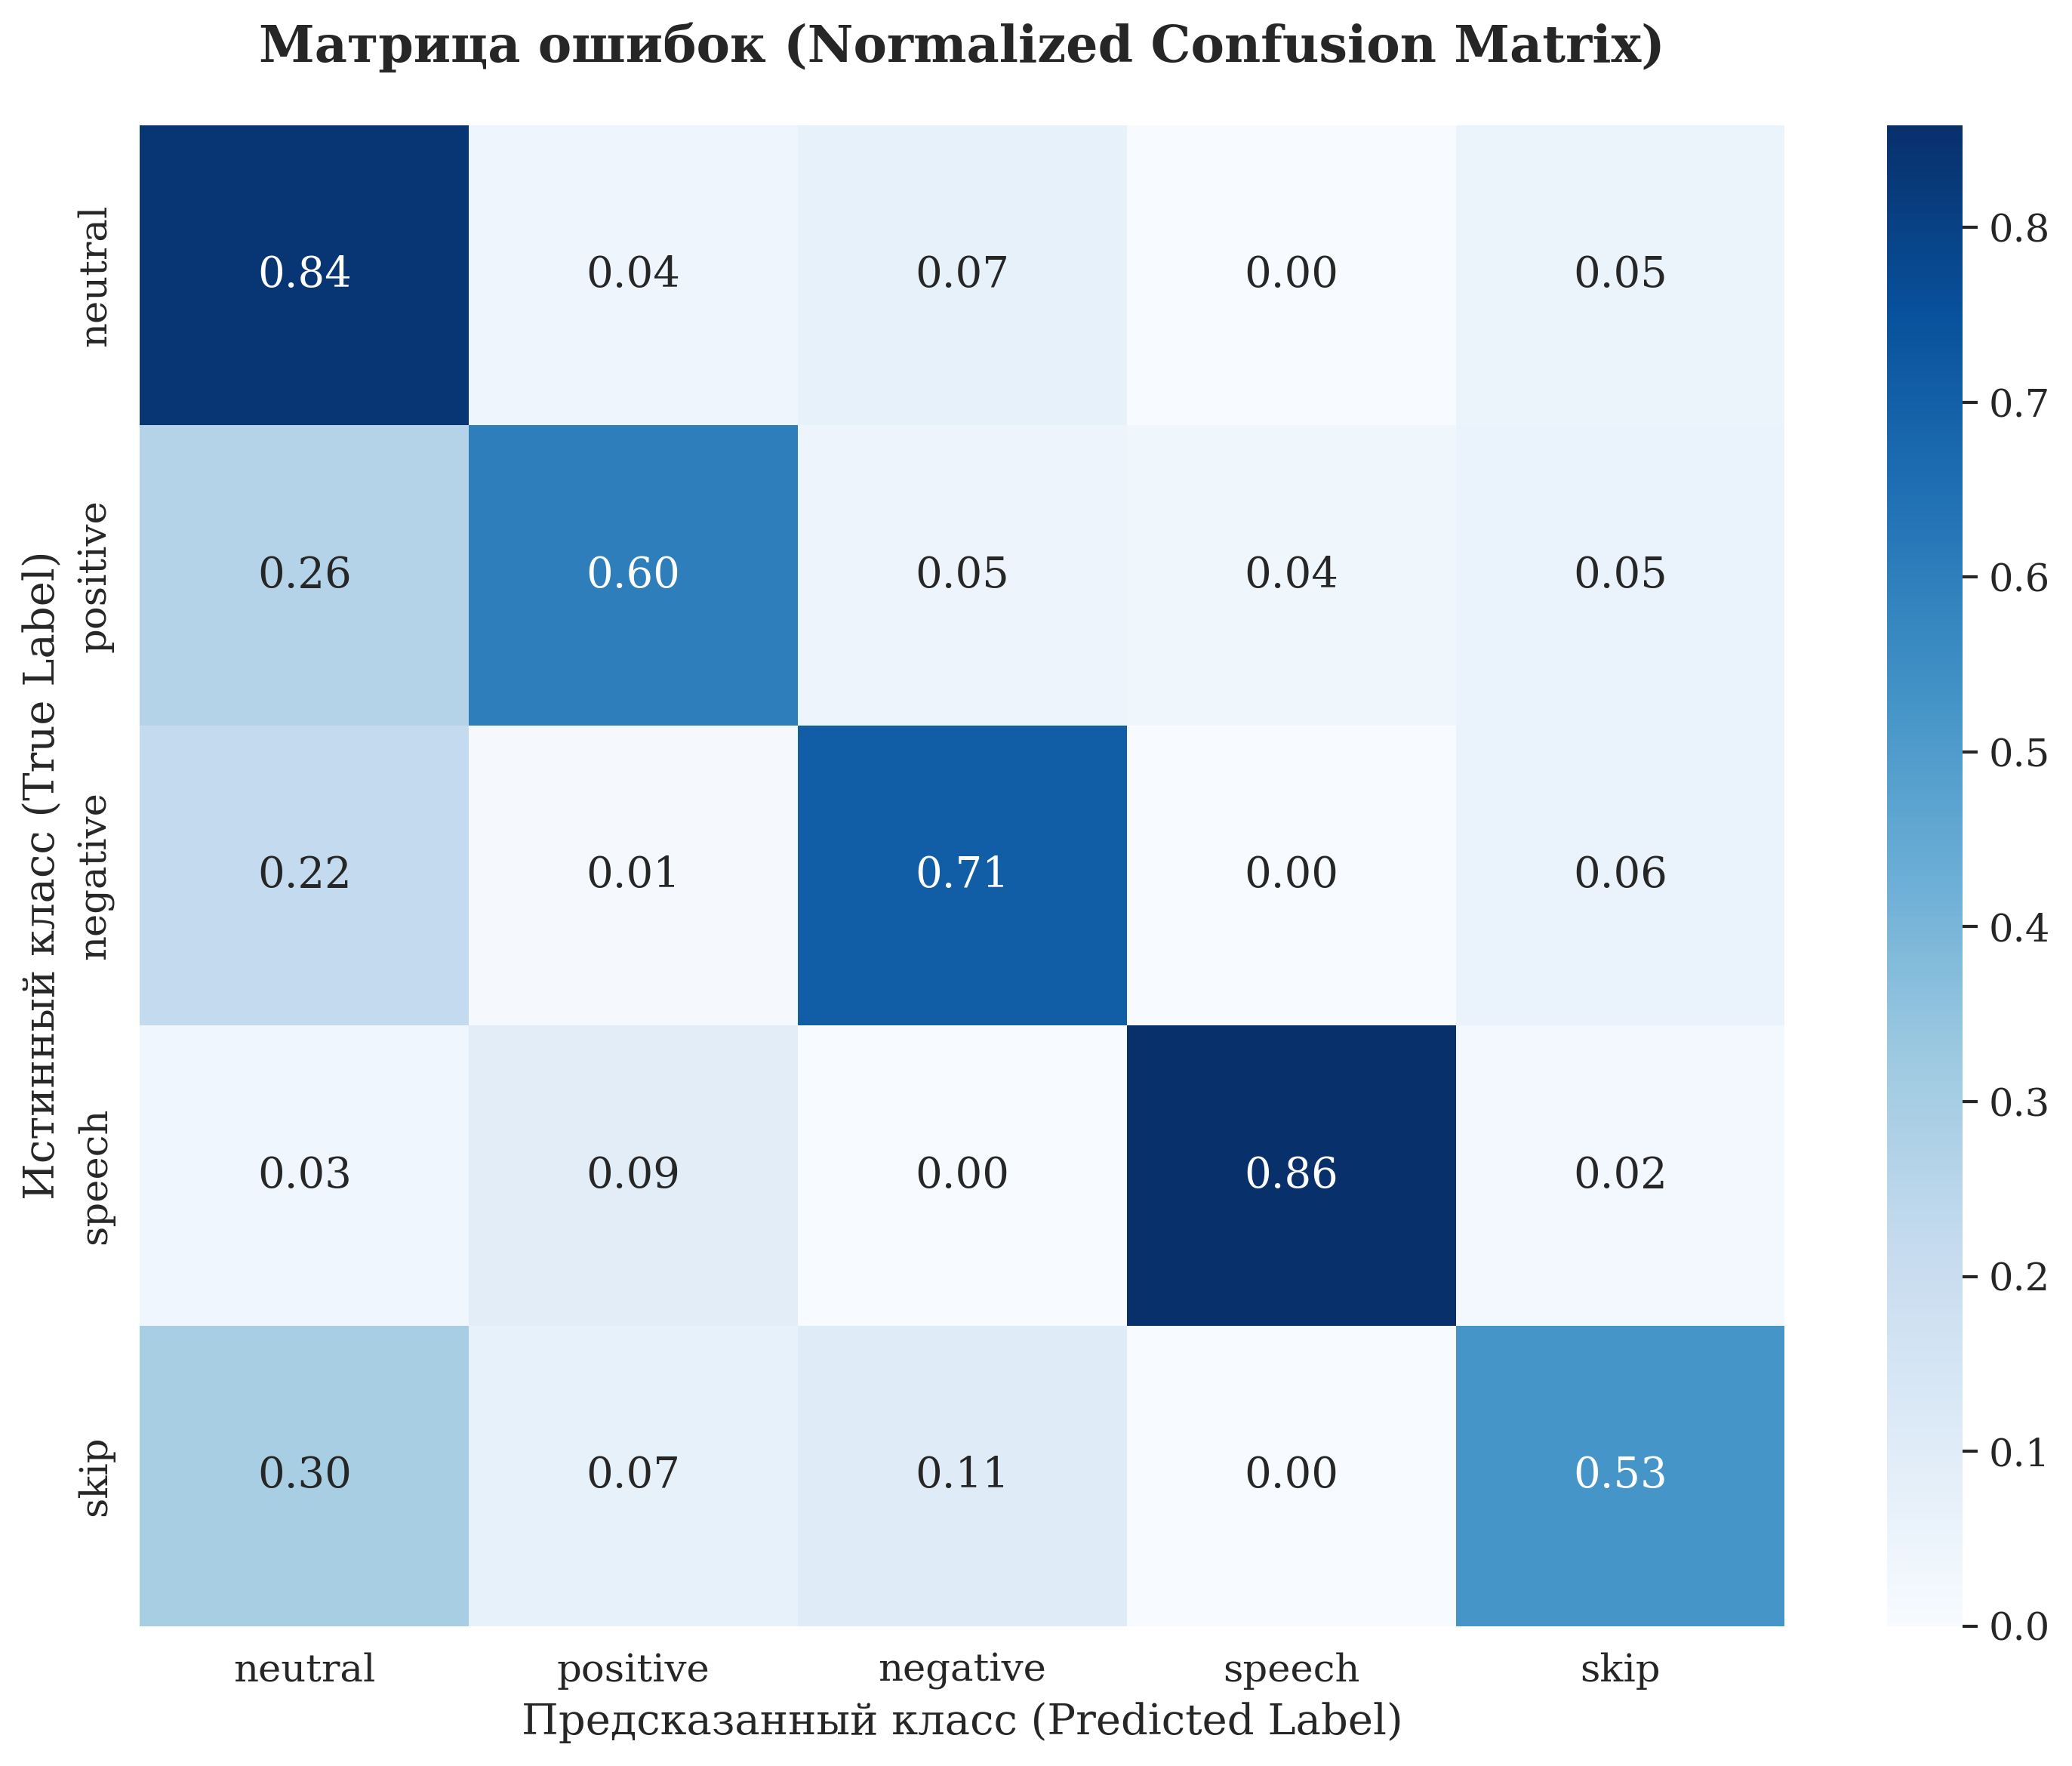

✅ Матрица ошибок сохранена: thesis_confusion_matrix.png


In [38]:
print("🔍 Выполняем предсказание на тестовом наборе...")
predictions_output = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions_output.predictions, axis=1)
labels = predictions_output.label_ids

# 2. Строим матрицу
cm = confusion_matrix(labels, preds)

# Нормализуем матрицу (чтобы видеть проценты, а не абсолютные числа)
# Это важно для диссертации, если классы несбалансированы
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 3. Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f', # Два знака после запятой
    cmap='Blues',
    xticklabels=[id2label[i] for i in range(len(id2label))],
    yticklabels=[id2label[i] for i in range(len(id2label))]
)

plt.title('Матрица ошибок (Normalized Confusion Matrix)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Истинный класс (True Label)')
plt.xlabel('Предсказанный класс (Predicted Label)')
plt.tight_layout()
plt.savefig('thesis_confusion_matrix.png')
plt.show()

print("✅ Матрица ошибок сохранена: thesis_confusion_matrix.png")